In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data = sns.load_dataset('fmri')
data.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [15]:
data['subject'].unique()

array(['s13', 's5', 's12', 's11', 's10', 's9', 's8', 's7', 's6', 's4',
       's3', 's2', 's1', 's0'], dtype=object)

In [16]:
machine = data[data['subject'] == 's1']

In [17]:
pivot = machine.pivot_table(
    index='timepoint',
    columns = 'region',
    values = 'signal'
)

pivot.head()

region,frontal,parietal
timepoint,,
0,-0.043493,-0.061080
1,-0.052927,-0.072667
2,-0.032293,-0.043683
3,0.047674,0.062612
4,0.157334,0.218268


In [35]:
pivot

region,frontal,parietal
timepoint,,
0,-0.043493,-0.061080
1,-0.052927,-0.072667
2,-0.032293,-0.043683
3,0.047674,0.062612
4,0.157334,0.218268
5,0.222226,0.345895
6,0.190083,0.373259
7,0.075559,0.280216
8,-0.049687,0.114442


# Visualizing Sensor Signal Over Time

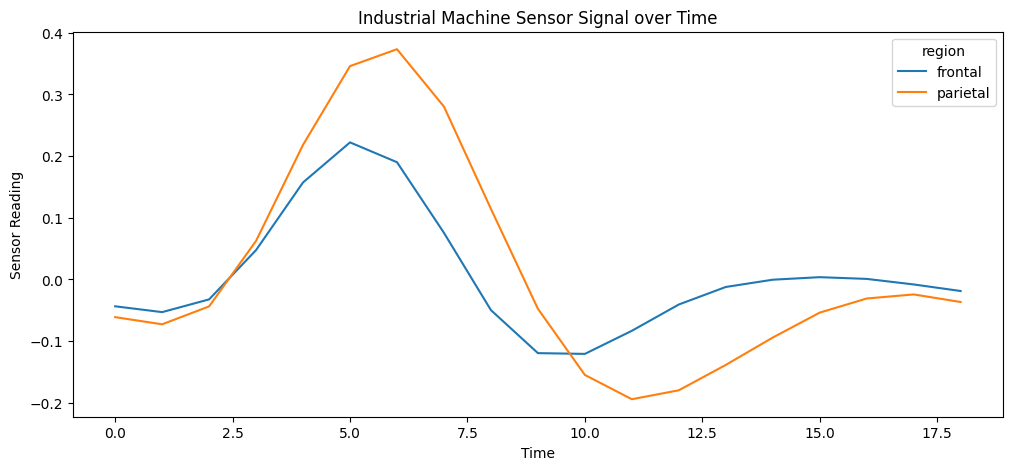

In [18]:
pivot.plot(figsize=(12,5))
plt.title("Industrial Machine Sensor Signal over Time")
plt.xlabel("Time")
plt.ylabel("Sensor Reading")
plt.show()

# Stationarity Check

In [19]:
data.isna().sum()

,0
subject,0
timepoint,0
event,0
region,0
signal,0


In [20]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [47]:
def adf_test(series,name):
  result = adfuller(series.dropna())
  print("ADF Statistic:", result[0])
  print(f"{name}: p-value = {result[1]: .4f}")

for col in pivot.columns:
  adf_test(pivot[col],col)

ADF Statistic: -7.421977647439015
frontal: p-value =  0.0000
ADF Statistic: -5.162139185598687
parietal: p-value =  0.0000


In [23]:
#help(adfuller)

Noise Reduction (MA smoothing)

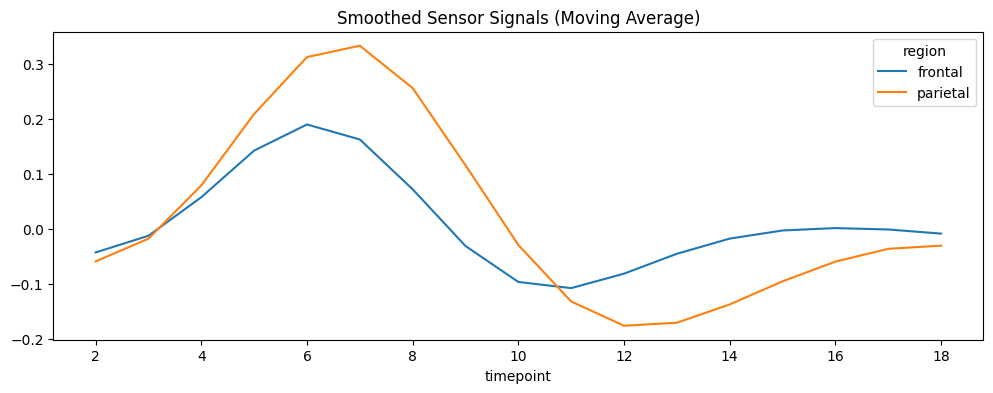

In [27]:

smoothed = pivot.rolling(window=3).mean()

smoothed.plot(figsize=(12,4))
plt.title("Smoothed Sensor Signals (Moving Average)")
plt.show()

# Shock Detection via Differencing

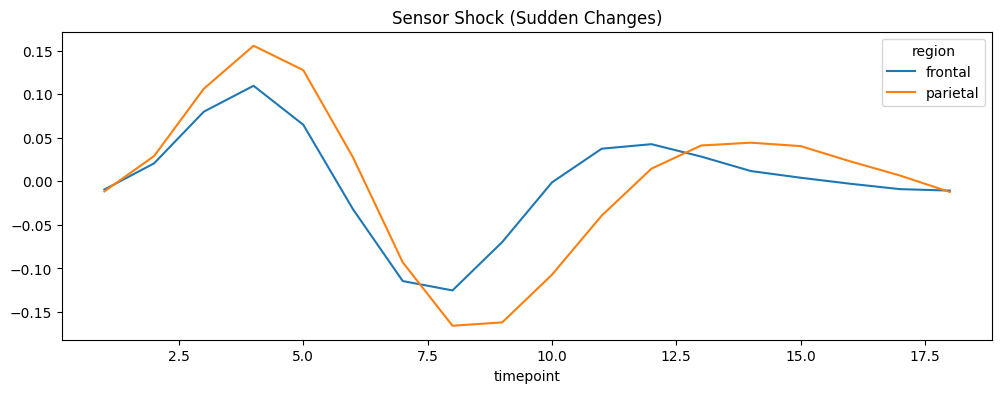

In [31]:
diff = pivot.diff()
diff.plot(figsize=(12,4))
plt.title("Sensor Shock (Sudden Changes)")
plt.show()

# Sensor correlation

In [32]:
pivot.corr()

region,frontal,parietal
region,,
frontal,1.000000,0.865162
parietal,0.865162,1.000000


In [34]:
#help(seasonal_decompose)

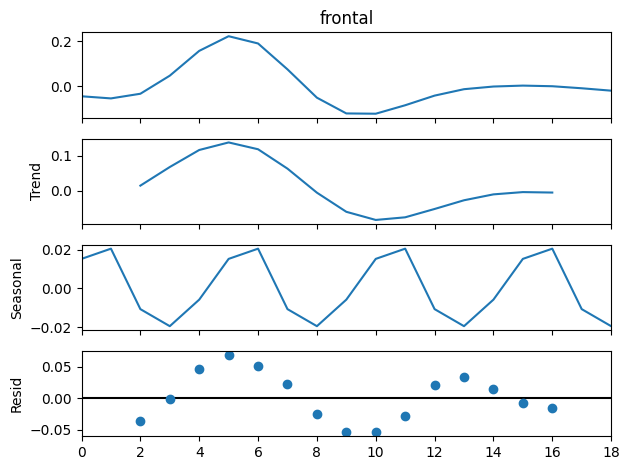

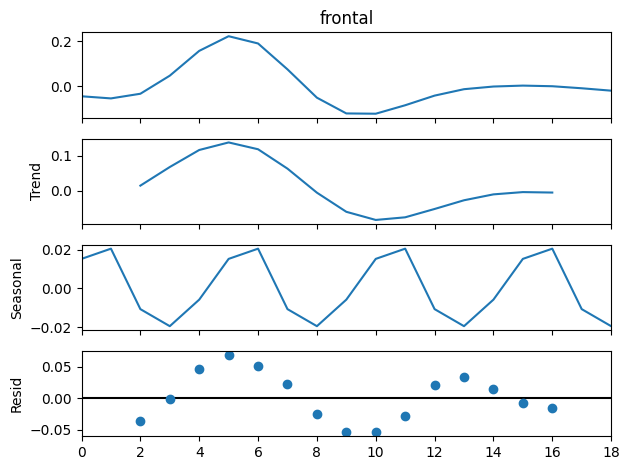

In [37]:
decomp = seasonal_decompose(pivot['frontal'],model='additive',period=5)

decomp.plot()

# Sunspot Activity Forecasting (Univariate)

In [38]:
from statsmodels.datasets import sunspots
from statsmodels.tsa.arima.model import ARIMA

In [44]:
data = sunspots.load_pandas().data

data = data.rename(columns = {"YEAR":'Year',
                       "SUNACTIVITY": 'Sunspots'})

data = data.set_index("Year")
data

,Sunspots
Year,
1700.0,5.0
1701.0,11.0
1702.0,16.0
1703.0,23.0
1704.0,36.0
...,...
2004.0,40.4
2005.0,29.8
2006.0,15.2


# Visualizing the Time Series

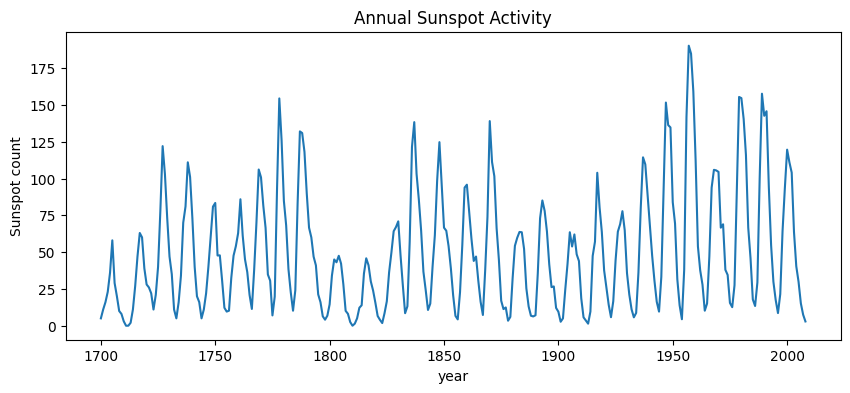

In [46]:
plt.figure(figsize=(10,4))
plt.plot(data['Sunspots'])
plt.title("Annual Sunspot Activity")
plt.xlabel("year")
plt.ylabel("Sunspot count")
plt.show()

In [51]:
for col in data.columns:
  adf_test(data[col],col)

ADF Statistic: -2.8377807249381943
Sunspots: p-value =  0.0531


# Moving Average to Reveal Cycles

* p <= 0.05, Stationary
* otherwise, non-stationary

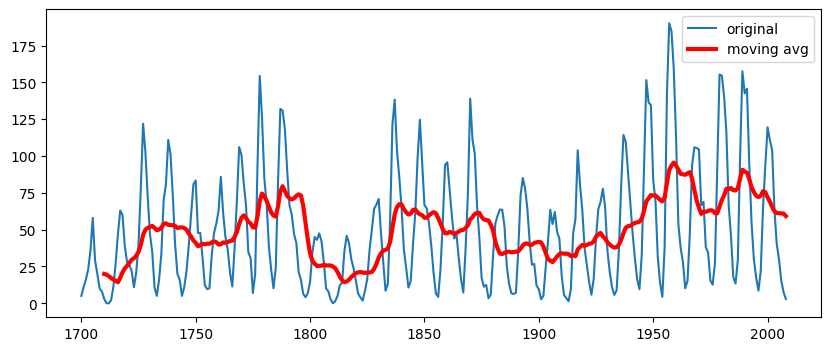

In [57]:

rolling_mean = data['Sunspots'].rolling(window=11).mean()

plt.figure(figsize=(10,4))
plt.plot(data['Sunspots'],label='original')
plt.plot(rolling_mean,label='moving avg', lw = 3, color = 'red')
plt.legend()
plt.show()

# AR model

In [58]:
model_ar  = ARIMA(data['Sunspots'],order=(2,0,0))
fit_ar = model_ar.fit()
print(fit_ar.summary())

#(AR order),d (Differencing order),q (MA order)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               Sunspots   No. Observations:                  309
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1307.319
Date:                Thu, 29 Jan 2026   AIC                           2622.637
Time:                        15:43:17   BIC                           2637.570
Sample:                             0   HQIC                          2628.607
                                - 309                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.7462      3.938     12.631      0.000      42.027      57.465
ar.L1          1.3906      0.037     37.694      0.000       1.318       1.463
ar.L2         -0.6886      0.036    -19.363      0.0

# MA Model

In [59]:
model_ma  = ARIMA(data['Sunspots'],order=(0,0,2))
fit_ma = model_ma.fit()
print(fit_ma.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:               Sunspots   No. Observations:                  309
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1358.404
Date:                Thu, 29 Jan 2026   AIC                           2724.809
Time:                        15:44:45   BIC                           2739.742
Sample:                             0   HQIC                          2730.779
                                - 309                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.5110      4.038     12.260      0.000      41.596      57.426
ma.L1          1.1879      0.041     28.649      0.000       1.107       1.269
ma.L2          0.6846      0.041     16.861      0.0

#ARMA model (best of AR and MA)



In [60]:
model_arma  = ARIMA(data['Sunspots'],order=(2,0,2))
fit_arma = model_arma.fit()
print(fit_arma.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               Sunspots   No. Observations:                  309
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1304.436
Date:                Thu, 29 Jan 2026   AIC                           2620.873
Time:                        15:46:03   BIC                           2643.273
Sample:                             0   HQIC                          2629.828
                                - 309                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.7502      3.667     13.567      0.000      42.563      56.938
ar.L1          1.4460      0.077     18.755      0.000       1.295       1.597
ar.L2         -0.7458      0.064    -11.681      0.0

# Forecasting future Sunspot Activity

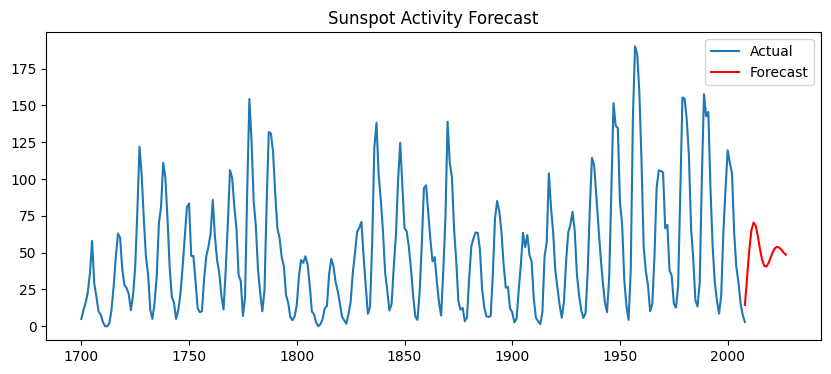

In [69]:
forecast = fit_arma.forecast(steps = 20)
forecast.index = pd.Index(range(2008,2008+20),name="Year")

plt.figure(figsize=(10,4))
plt.plot(data['Sunspots'],label='Actual')
plt.plot(forecast,label='Forecast',color='red')
plt.legend()
plt.title('Sunspot Activity Forecast')
plt.show()